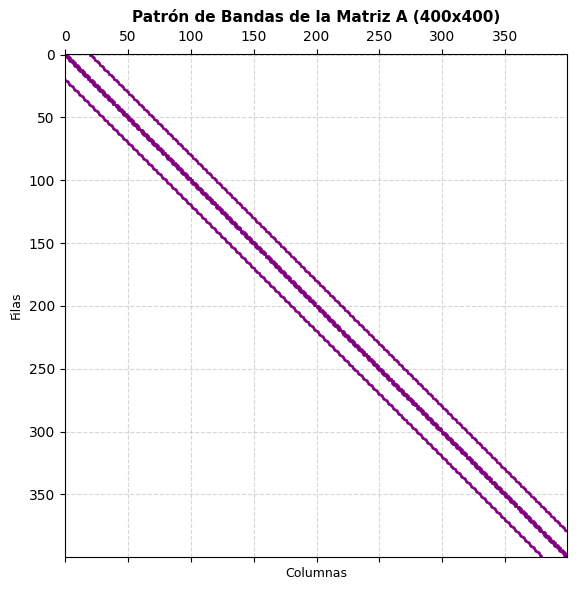

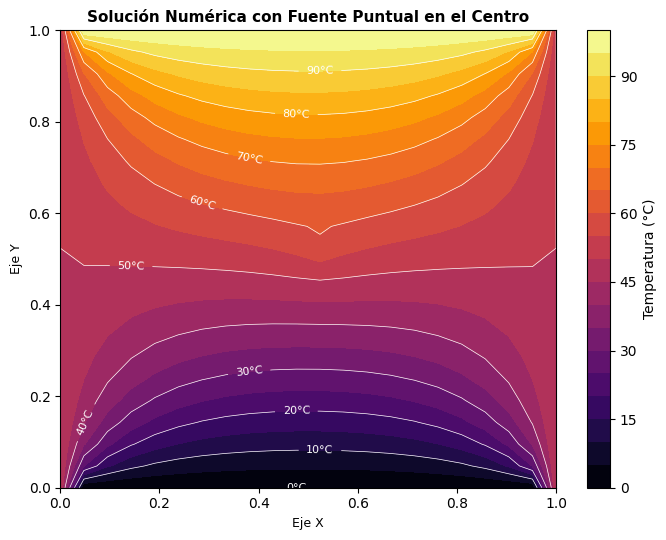

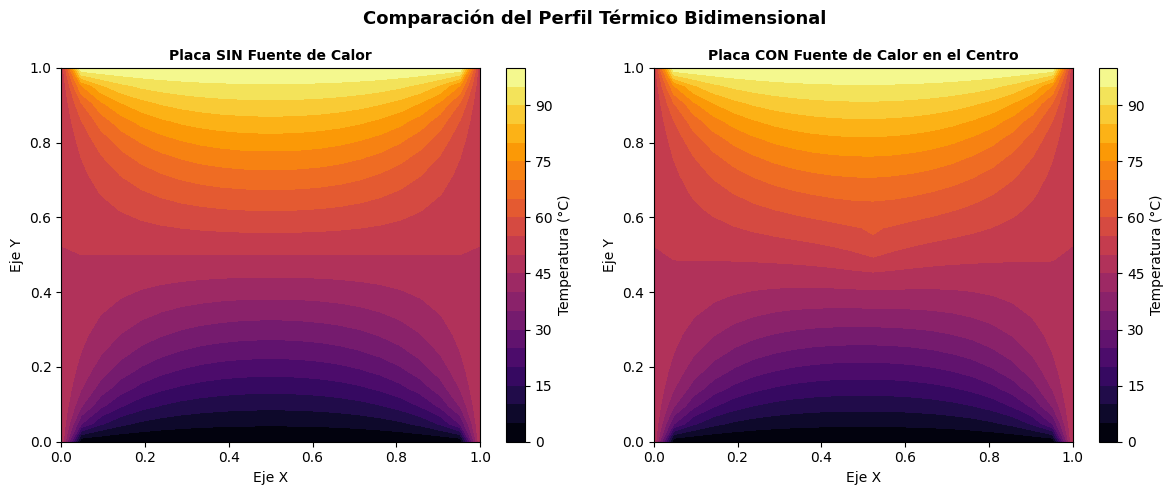

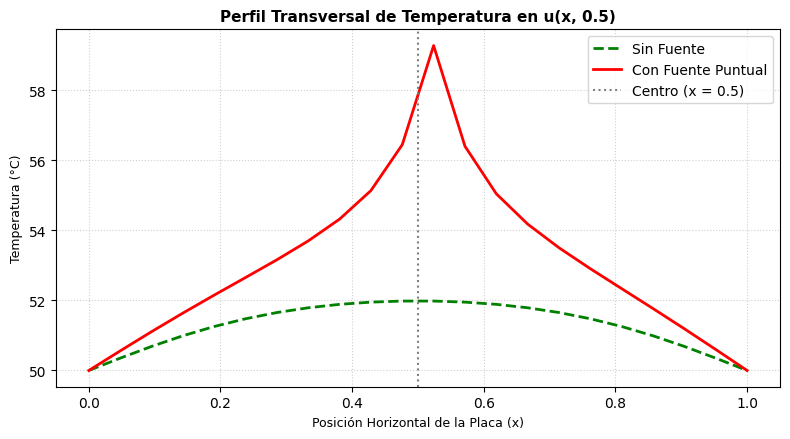

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def resolver_transferencia_calor(con_fuente=True):
    # Definición de parámetros del problema
    n = 20  # Número de nodos internos por lado
    N = n * n  # Total de incógnitas (400)
    h = 1.0 / (n + 1)  # Tamaño del paso espacial

    # Temperaturas de frontera (Dirichlet)
    T_sup = 100.0
    T_inf = 0.0
    T_izq = 50.0
    T_der = 50.0

    # Inicialización de la Matriz A
    A = lil_matrix((N, N))
    b = np.zeros(N)

    # Configuración de la fuente de calor puntual
    # El centro de los nodos internos (de 0 a 19) está entre las posiciones 9 y 10
    # Posicionamos la fuente en el centro aproximado (i=10, j=10)
    if con_fuente:
        intensidad_fuente = 5000.0
        b[10 * n + 10] = (h ** 2) * intensidad_fuente

    # Ensamblaje del sistema lineal Au = b
    for j in range(1, n + 1):  # Filas (y)
        for i in range(1, n + 1):  # Columnas (x)

            k = (j - 1) * n + (i - 1)

            # Diagonal principal
            A[k, k] = 4.0

            # Vecino Izquierdo (i - 1)
            if i == 1:
                b[k] += T_izq
            else:
                A[k, k - 1] = -1.0

            # Vecino Derecho (i + 1)
            if i == n:
                b[k] += T_der
            else:
                A[k, k + 1] = -1.0

            # Vecino Inferior (j - 1)
            if j == 1:
                b[k] += T_inf
            else:
                A[k, k - n] = -1.0

            # Vecino Superior (j + 1)
            if j == n:
                b[k] += T_sup
            else:
                A[k, k + n] = -1.0

    # Convertimos la matriz A a formato CSR para una resolución matemática óptima
    A_csr = A.tocsr()

    # Resolvemos el sistema de ecuaciones lineales
    u_lineal = spsolve(A_csr, b)

    # Reconstruimos la matriz de la placa completa incluyendo los bordes conocidos
    placa_completa = np.zeros((n + 2, n + 2))

    # Asignamos los nodos internos resueltos
    placa_completa[1:n+1, 1:n+1] = u_lineal.reshape((n, n))

    # Imponemos las condiciones de contorno en los bordes de la matriz final
    placa_completa[n + 1, :] = T_sup  # Fila superior
    placa_completa[0, :] = T_inf      # Fila inferior
    placa_completa[:, 0] = T_izq      # Columna izquierda
    placa_completa[:, n + 1] = T_der  # Columna derecha

    return A_csr, placa_completa, n, h

# Resolvmos ambos escenarios con y sin fuente de calor
A_matriz, placa_con, n, h = resolver_transferencia_calor(con_fuente=True)
_, placa_sin, _, _ = resolver_transferencia_calor(con_fuente=False)

# Creamos grilla de coordenadas para graficar
x = np.linspace(0, 1, n + 2)
y = np.linspace(0, 1, n + 2)
X, Y = np.meshgrid(x, y)

# Visualización del patrón de bandas de la Matriz A
plt.figure(figsize=(6, 6))
plt.spy(A_matriz, markersize=1, color='purple')
plt.title("Patrón de Bandas de la Matriz A (400x400)", fontsize=11, fontweight='bold')
plt.xlabel("Columnas", fontsize=9)
plt.ylabel("Filas", fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Mapa de calor con curvas de nivel (Con Fuente)
plt.figure(figsize=(7, 5.5))
contour_con = plt.contourf(X, Y, placa_con, levels=20, cmap='inferno')
plt.colorbar(contour_con, label='Temperatura (°C)')
lineas_con = plt.contour(X, Y, placa_con, levels=10, colors='white', linewidths=0.5)
plt.clabel(lineas_con, inline=True, fontsize=8, fmt='%1.0f°C')
plt.title("Solución Numérica con Fuente Puntual en el Centro", fontsize=11, fontweight='bold')
plt.xlabel("Eje X", fontsize=9)
plt.ylabel("Eje Y", fontsize=9)
plt.tight_layout()
plt.show()

# Análisis Físico - Comparación Con vs Sin Fuente
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico sin fuente
c1 = axs[0].contourf(X, Y, placa_sin, levels=20, cmap='inferno')
fig.colorbar(c1, ax=axs[0], label='Temperatura (°C)')
axs[0].set_title("Placa SIN Fuente de Calor", fontsize=10, fontweight='bold')
axs[0].set_xlabel("Eje X")
axs[0].set_ylabel("Eje Y")

# Gráfico con fuente
c2 = axs[1].contourf(X, Y, placa_con, levels=20, cmap='inferno')
fig.colorbar(c2, ax=axs[1], label='Temperatura (°C)')
axs[1].set_title("Placa CON Fuente de Calor en el Centro", fontsize=10, fontweight='bold')
axs[1].set_xlabel("Eje X")
axs[1].set_ylabel("Eje Y")

plt.suptitle("Comparación del Perfil Térmico Bidimensional", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Perfil Transversal en y = 0.5
# El nodo central en 'y' corresponde aproximadamente al índice medio de la grilla
idx_centro = (n + 2) // 2

plt.figure(figsize=(8, 4.5))
plt.plot(x, placa_sin[idx_centro, :], 'g--', label='Sin Fuente', linewidth=2)
plt.plot(x, placa_con[idx_centro, :], 'r-', label='Con Fuente Puntual', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle=':', label='Centro (x = 0.5)')

plt.title("Perfil Transversal de Temperatura en u(x, 0.5)", fontsize=11, fontweight='bold')
plt.xlabel("Posición Horizontal de la Placa (x)", fontsize=9)
plt.ylabel("Temperatura (°C)", fontsize=9)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()